# Exploratory Data Analisis (EDA)


In [1]:
# libraries
import os
import pandas as pd
import shutil
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup as bs
from chromedriver_py import binary_path
import requests
import warnings; warnings.filterwarnings("ignore")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
players_df = pd.read_csv("raw_data/players.csv")
teams_df = pd.read_csv("raw_data/all_teams_data.csv")

# 1. Missing data

In [11]:
print(players_df.info())
print(players_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19612 entries, 0 to 19611
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  19612 non-null  object 
 1   Age     19612 non-null  int64  
 2   Team    19612 non-null  object 
 3   Pos     19612 non-null  object 
 4   G       19612 non-null  int64  
 5   GS      19612 non-null  int64  
 6   MP      19612 non-null  float64
 7   FG      19612 non-null  float64
 8   FGA     19612 non-null  float64
 9   FG%     19612 non-null  float64
 10  3P      19612 non-null  float64
 11  3PA     19612 non-null  float64
 12  3P%     19612 non-null  float64
 13  2P      19612 non-null  float64
 14  2PA     19612 non-null  float64
 15  2P%     19612 non-null  float64
 16  eFG%    19612 non-null  float64
 17  FT      19612 non-null  float64
 18  FTA     19612 non-null  float64
 19  FT%     19612 non-null  float64
 20  ORB     19612 non-null  float64
 21  DRB     19612 non-null  float64
 22

In [15]:
print(teams_df.info())
print(teams_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 909
Data columns (total 42 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Team           909 non-null    object 
 1   Year           909 non-null    int64  
 2   Champion       909 non-null    object 
 3   fg_per_g       909 non-null    float64
 4   fga_per_g      909 non-null    float64
 5   fg_pct         909 non-null    float64
 6   fg2_per_g      909 non-null    float64
 7   fg2a_per_g     909 non-null    float64
 8   fg2_pct        909 non-null    float64
 9   fg3_per_g      909 non-null    float64
 10  fg3a_per_g     909 non-null    float64
 11  fg3_pct        909 non-null    float64
 12  ft_per_g       909 non-null    float64
 13  fta_per_g      909 non-null    float64
 14  ft_pct         909 non-null    float64
 15  orb_per_g      909 non-null    float64
 16  drb_per_g      909 non-null    float64
 17  trb_per_g      909 non-null    float64
 18  ast_per_g      

In [8]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    print(team_df.info())
    print("""
----------------------------------------------------------------------------
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 76 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mp                    82 non-null     int64  
 1   fg                    82 non-null     int64  
 2   fga                   82 non-null     int64  
 3   fg_pct                82 non-null     float64
 4   fg3                   82 non-null     int64  
 5   fg3a                  82 non-null     int64  
 6   fg3_pct               82 non-null     float64
 7   ft                    82 non-null     int64  
 8   fta                   82 non-null     int64  
 9   ft_pct                82 non-null     float64
 10  orb                   82 non-null     int64  
 11  drb                   82 non-null     int64  
 12  trb                   82 non-null     int64  
 13  ast                   82 non-null     int64  
 14  stl                   82 non-null     int64  
 15  blk                   82 

# 2. Correlation analysis

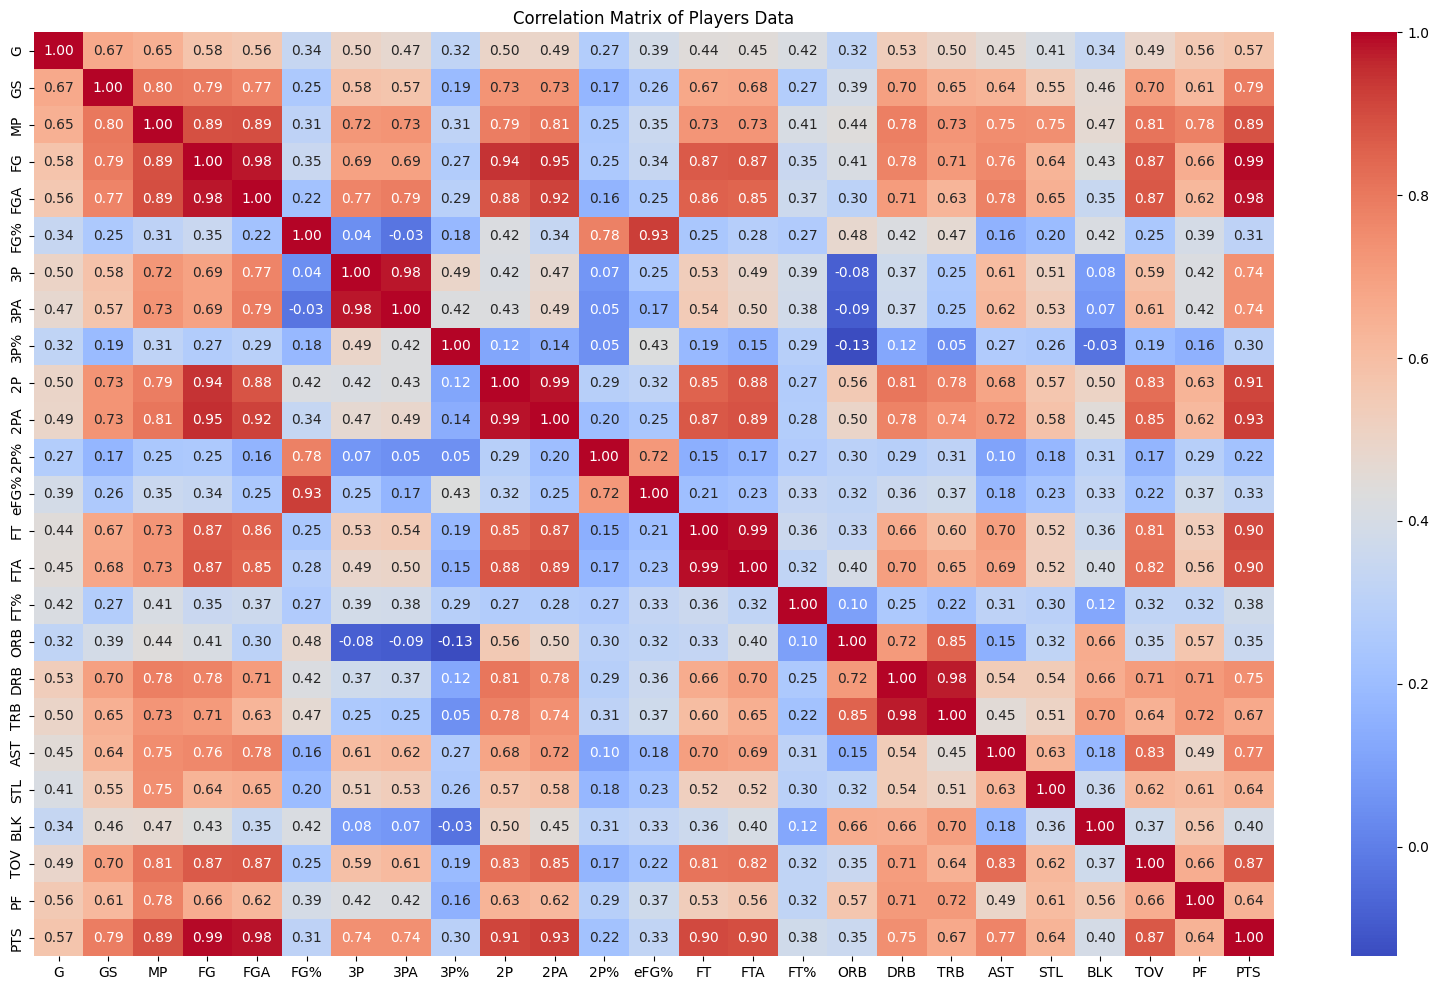

In [7]:
year = 2024
players_df_year = players_df[players_df['Year'] == year]
players_df_year = players_df_year.drop(columns=["Age", "Year"])
correlation_matrix_players = players_df_year.corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix_players, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Players Data')
plt.show()

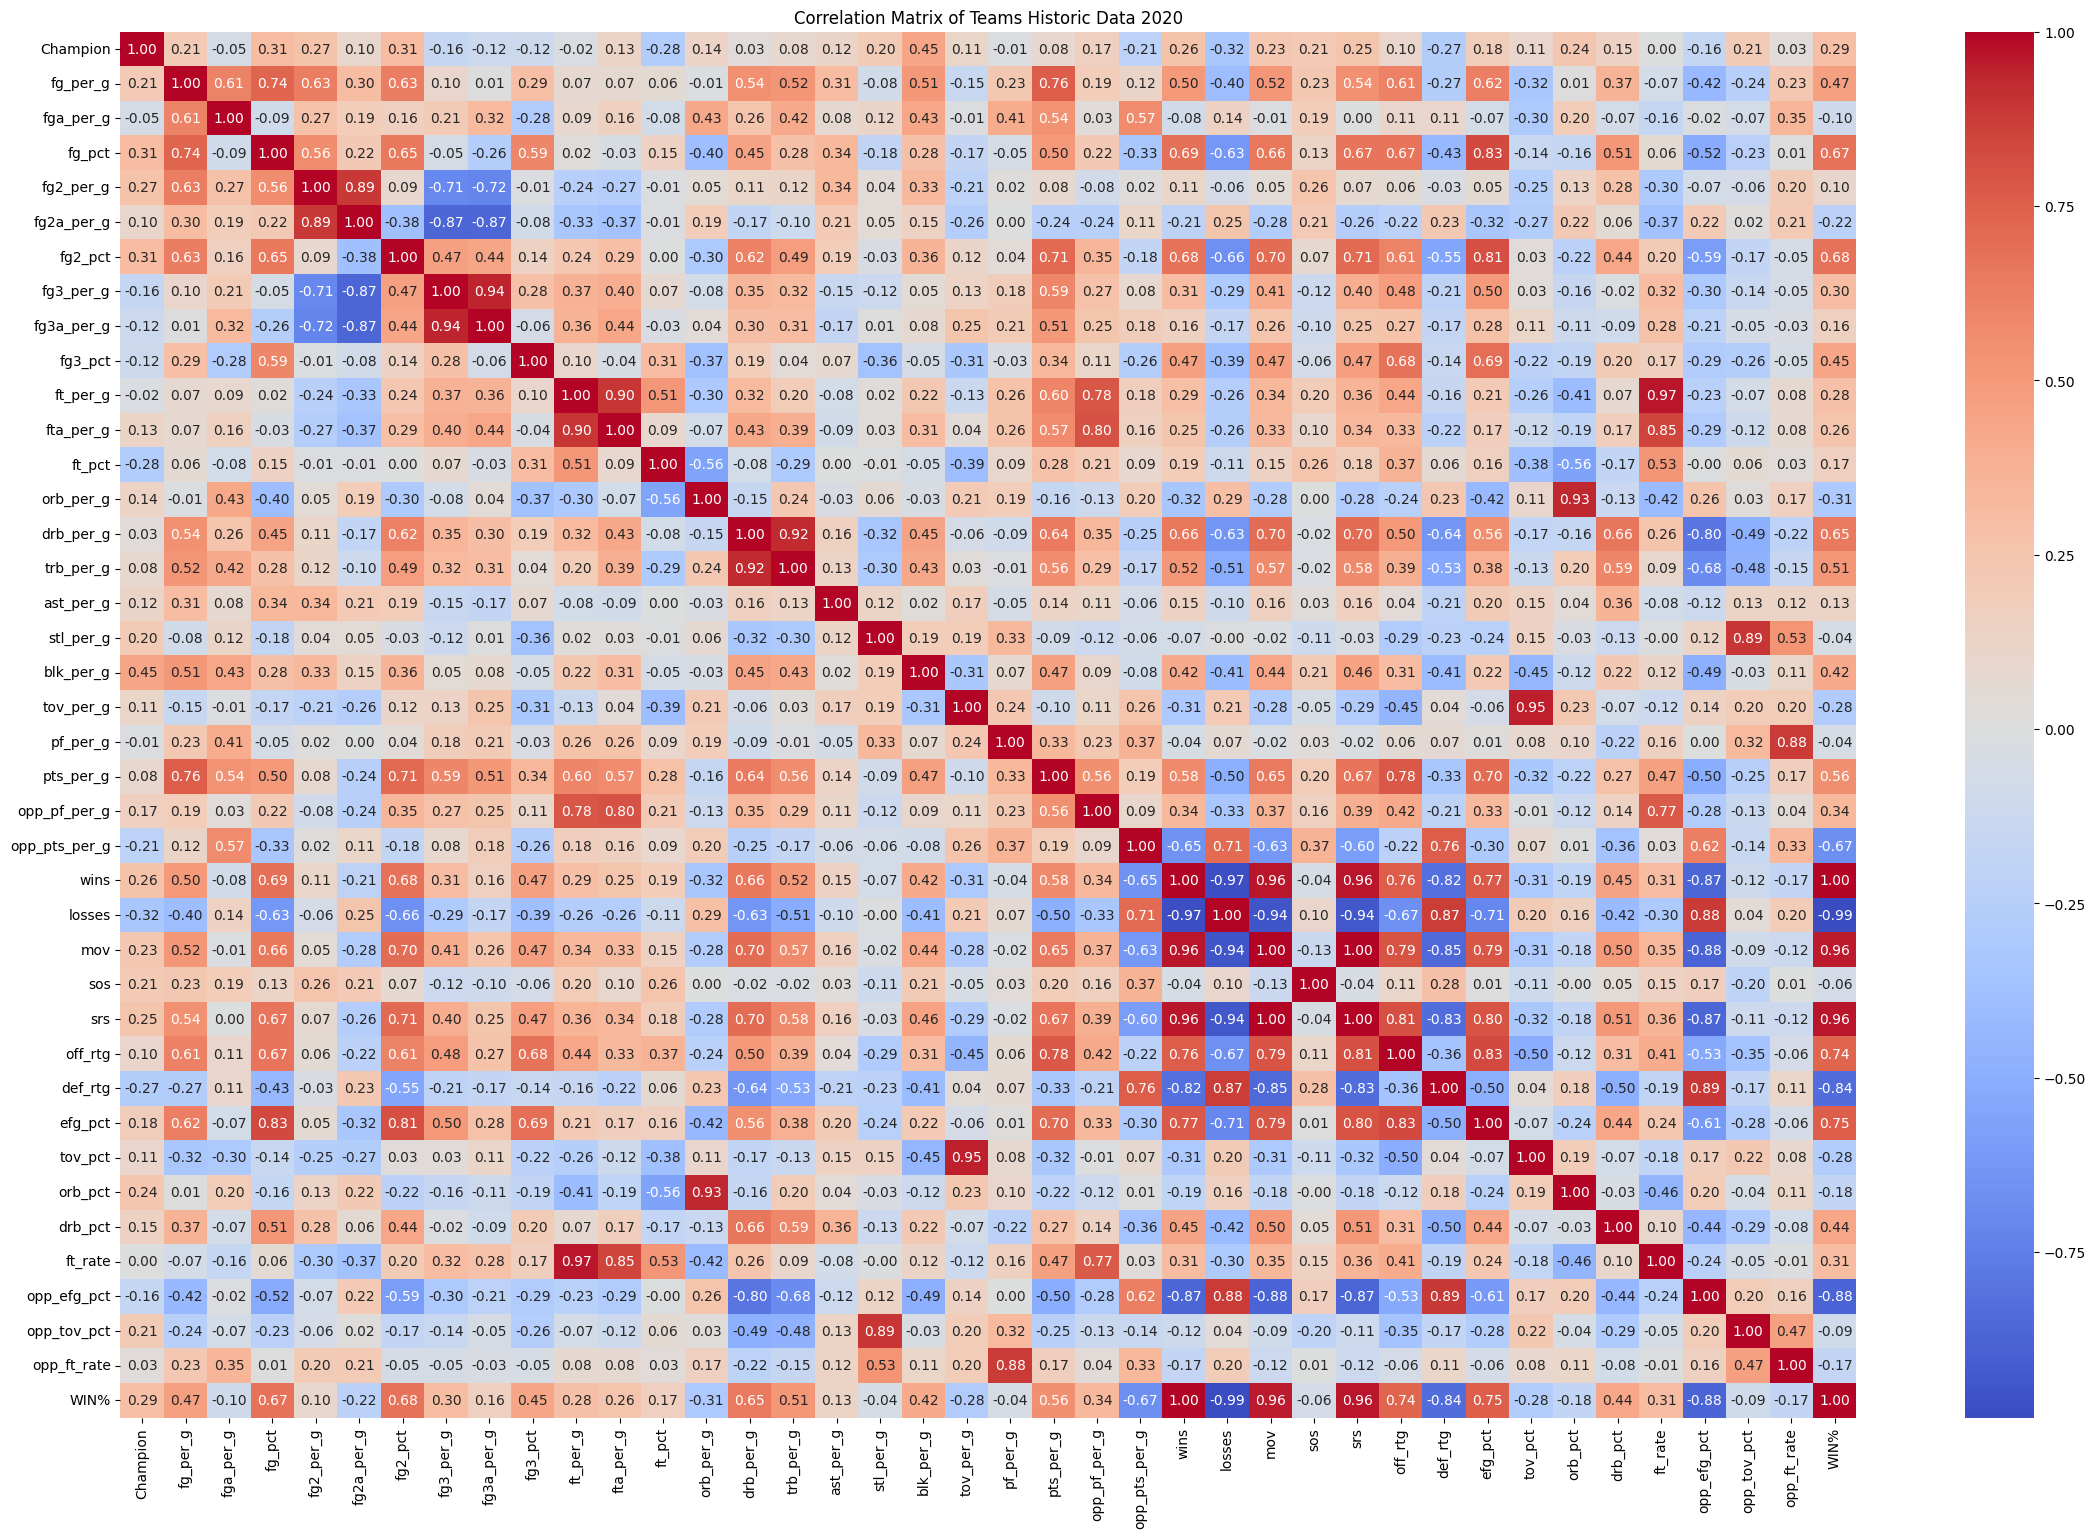

In [31]:
# teams_df["Champion"] = teams_df["Champion"].replace({"Yes": 1, "No": 0})
year = 2020
team_df_year = teams_df[teams_df["Year"] == year]
team_df_year= team_df_year.drop(columns=["Year"])
correlation_matrix_teams = team_df_year.corr(numeric_only=True)

plt.figure(figsize=(28, 18))
sns.heatmap(correlation_matrix_teams, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Correlation Matrix of Teams Historic Data {year}')
plt.show()

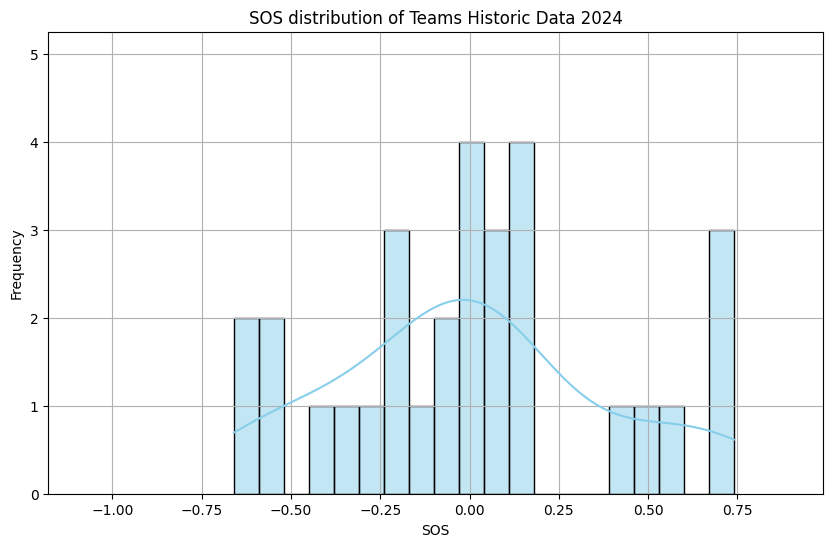

In [30]:
range_x = ((teams_df[teams_df["Year"] >= 2020])['sos'].min()-0.25, (teams_df[teams_df["Year"] >= 2020])['sos'].max()+0.25)
range_y = (0, 5.25)

plt.figure(figsize=(10, 6))
sns.histplot(team_df_year['sos'], kde=True, color='skyblue', bins=20)
plt.xlim(range_x)
plt.ylim(range_y)

plt.title(f'SOS distribution of Teams Historic Data {year}')
plt.xlabel('SOS')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [26]:
team_df_year['sos'].min()
# min: -0.32, -0.56, -0.35
# max: 0.51, 0.37, 0.49

np.float64(-0.66)

# 3. Canonical Correlation Analysis (CCA)

In [3]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

<Figure size 1500x1500 with 0 Axes>

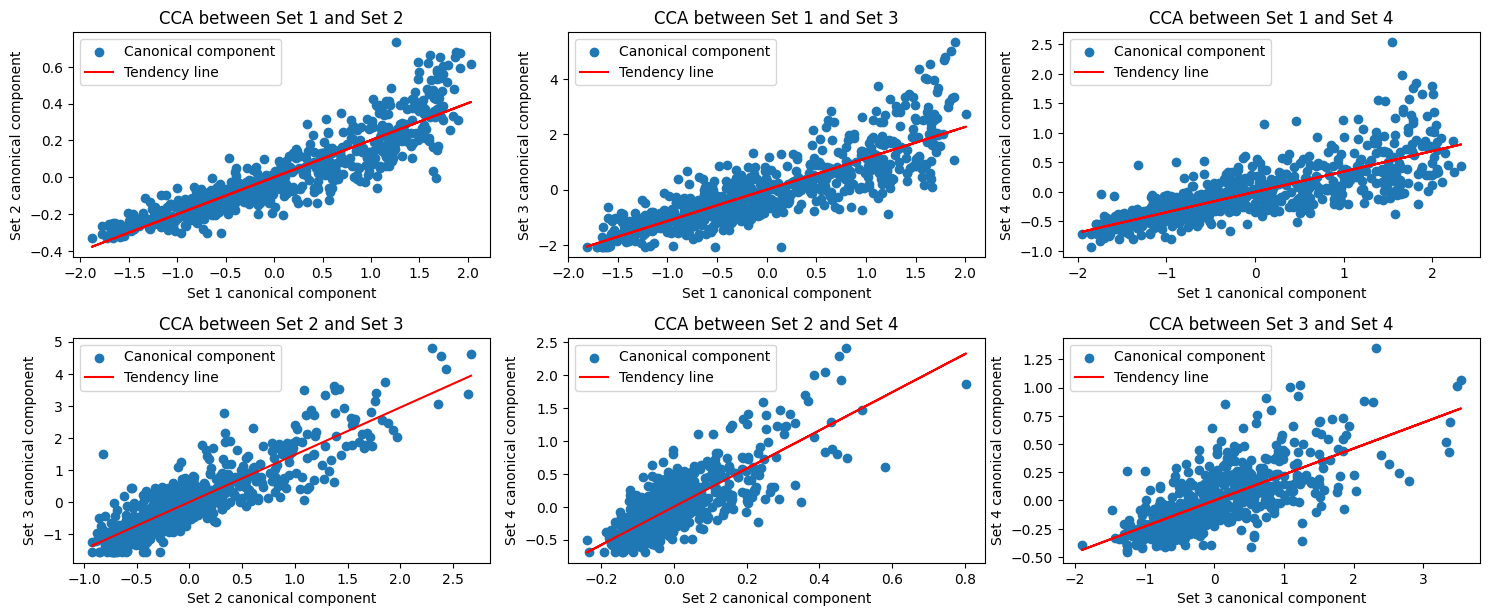

In [62]:
year = 2020
players_df_year = players_df[players_df['Year'] == year]
players_df_year = players_df_year.drop(columns=["Age", "Year"])
set1 = players_df_year[['G','GS','MP']]
set2 = players_df_year[['PTS', 'FG', 'FGA', '2P', '2PA', 'FT', 'FTA', '3P', '3PA']]
set3 = players_df_year[['AST', 'TOV', 'STL']]
set4 = players_df_year[['TRB', 'ORB', 'DRB']]
# set5 = players_df[['FG%', '2P%', 'eFG%']]

plt.figure(figsize=(15, 15))

sets = [set1, set2, set3, set4]
set_scaled = []

scaler = StandardScaler()
for set_ in sets:
    set_scaled.append(scaler.fit_transform(set_))

cca = []

for i in range(4):
    for j in range(i+1, 4):
        cca.append(CCA(n_components=1))
        cca[-1].fit(set_scaled[i], set_scaled[j])

plt.figure(figsize=(15, 15))

plot_index = 1
for i in range(4):
    for j in range(i+1, 4):
        set_i_c, set_j_c = cca[plot_index - 1].transform(set_scaled[i], set_scaled[j])
        x = set_i_c[:, 0]
        y = set_j_c[:, 0]

        # Ajuste de línea de regresión
        coeffs = np.polyfit(x, y, deg=1)
        trendline = np.poly1d(coeffs)
        y_trend = trendline(x)

        plt.subplot(5, 3, plot_index)
        plt.scatter(x, y, label='Canonical component')
        plt.plot(x, y_trend, color='red', label='Tendency line')
        plt.xlabel(f'Set {i+1} canonical component')
        plt.ylabel(f'Set {j+1} canonical component')
        plt.legend()
        plt.title(f'CCA between Set {i+1} and Set {j+1}')
        plot_index += 1

plt.tight_layout()
plt.show()

In [58]:
import numpy as np

def compute_canonical_correlations(cca, X, Y):
    X_c, Y_c = cca.transform(X, Y)
    return np.corrcoef(X_c.T, Y_c.T).diagonal(offset=X_c.shape[1])

combinations = [
    (0, set_scaled[0], set_scaled[1], "Set 1 - Set 2"),
    (1, set_scaled[0], set_scaled[2], "Set 1 - Set 3"),
    (2, set_scaled[0], set_scaled[3], "Set 1 - Set 4"),
    (3, set_scaled[1], set_scaled[2], "Set 2 - Set 3"),
    (4, set_scaled[1], set_scaled[3], "Set 2 - Set 4"),
    (5, set_scaled[2], set_scaled[3], "Set 3 - Set 4"),
]

for idx, X, Y, name in combinations:
    canonical_corrs = compute_canonical_correlations(cca[idx], X, Y)
    print(f"Correlaciones canónicas para {name}: {canonical_corrs[0]:.4f}")

Correlaciones canónicas para Set 1 - Set 2: 0.9149
Correlaciones canónicas para Set 1 - Set 3: 0.8746
Correlaciones canónicas para Set 1 - Set 4: 0.8120
Correlaciones canónicas para Set 2 - Set 3: 0.8956
Correlaciones canónicas para Set 2 - Set 4: 0.8346
Correlaciones canónicas para Set 3 - Set 4: 0.7509


<Figure size 1500x1500 with 0 Axes>

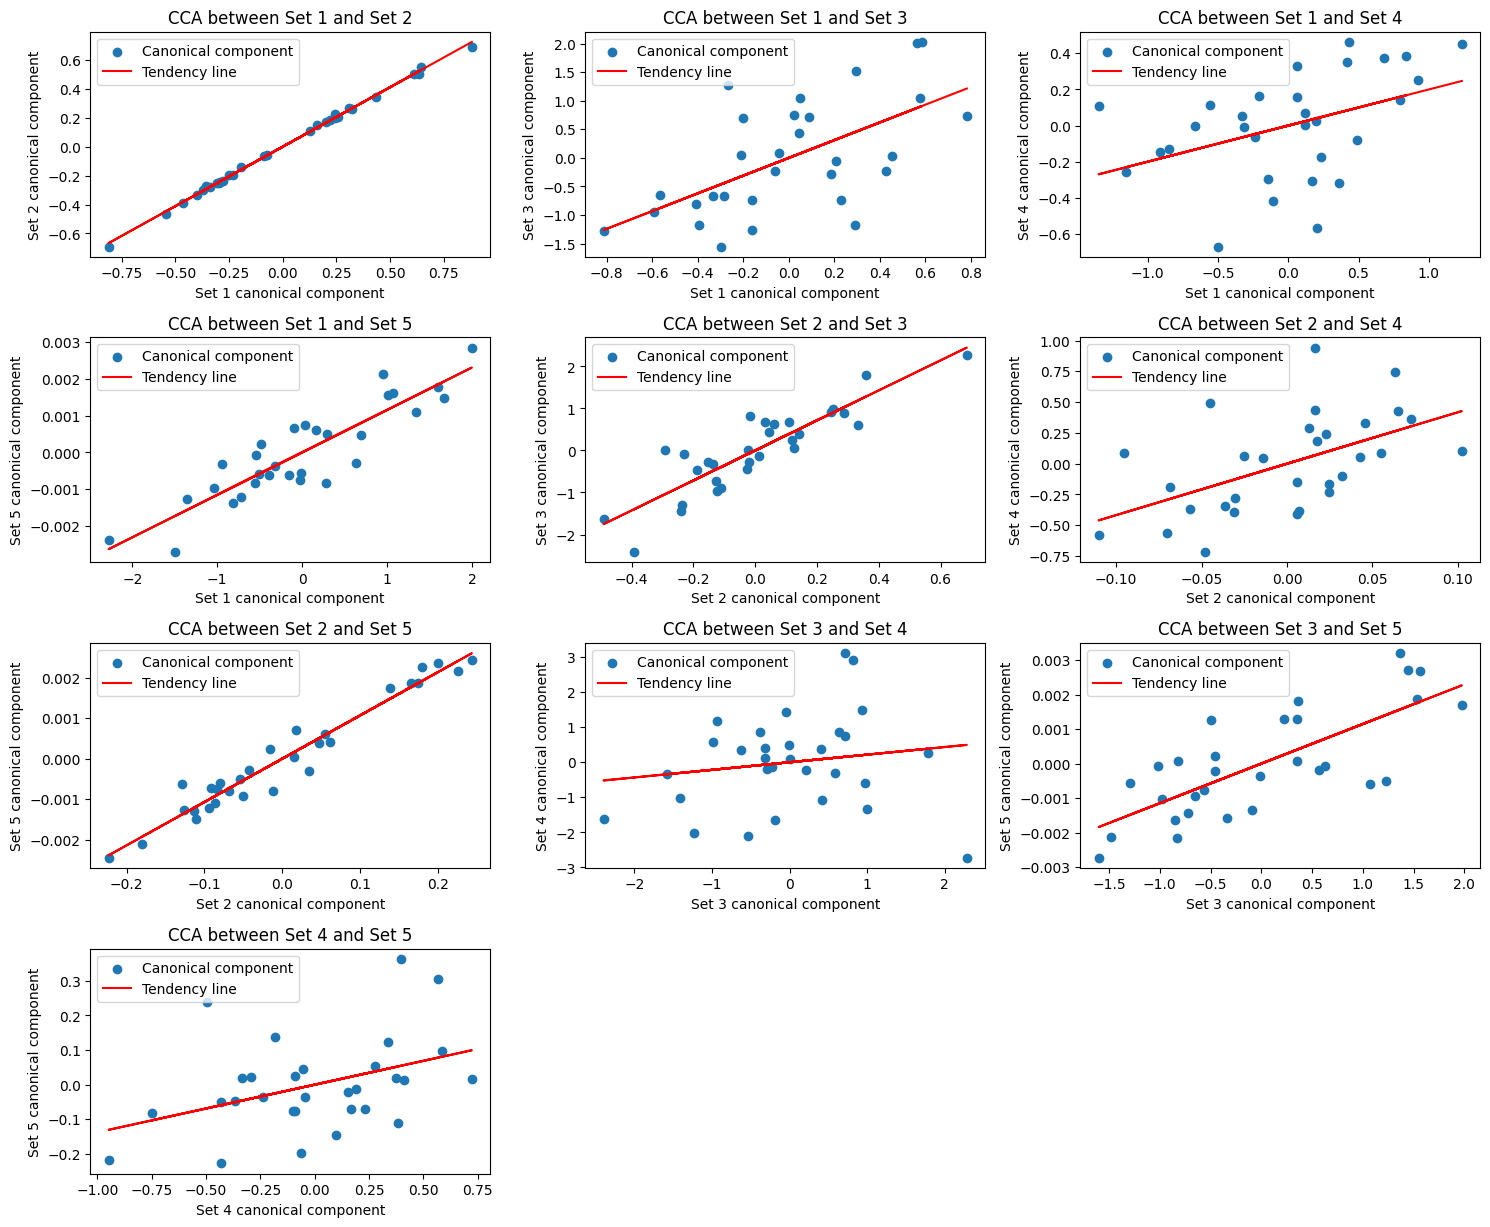

In [74]:
# Fill missing values with the mean of the respective columns
year = 2024
team_df_year = teams_df[teams_df["Year"] == year]
team_df_year= team_df_year.drop(columns=["Year"])

set1 = team_df_year[['def_rtg', 'opp_pts_per_g', 'opp_efg_pct']]
set2 = team_df_year[['pts_per_g', 'fg_per_g', 'fga_per_g', 'fg2_per_g', 'fg2a_per_g', 'fg3_per_g', 'fg3a_per_g', 'off_rtg']]
set3 = team_df_year[['ast_per_g', 'tov_per_g']]
set4 = team_df_year[['pf_per_g', 'opp_ft_rate']]
set5 = team_df_year[['mov', 'sos', 'srs', 'WIN%']]
sets = [set1, set2, set3, set4, set5]
set_scaled = []

plt.figure(figsize=(15, 15))

scaler = StandardScaler()
for set_ in sets:
    set_scaled.append(scaler.fit_transform(set_))

cca = []

for i in range(5):
    for j in range(i+1, 5):
        cca.append(CCA(n_components=1))
        cca[-1].fit(set_scaled[i], set_scaled[j])

plt.figure(figsize=(15, 15))

plot_index = 1
for i in range(5):
    for j in range(i+1, 5):
        set_i_c, set_j_c = cca[plot_index - 1].transform(set_scaled[i], set_scaled[j])
        x = set_i_c[:, 0]
        y = set_j_c[:, 0]

        # Ajuste de línea de regresión
        coeffs = np.polyfit(x, y, deg=1)
        trendline = np.poly1d(coeffs)
        y_trend = trendline(x)

        plt.subplot(5, 3, plot_index)
        plt.scatter(x, y, label='Canonical component')
        plt.plot(x, y_trend, color='red', label='Tendency line')  # Línea roja
        plt.xlabel(f'Set {i+1} canonical component')
        plt.ylabel(f'Set {j+1} canonical component')
        plt.legend()
        plt.title(f'CCA between Set {i+1} and Set {j+1}')
        plot_index += 1

plt.tight_layout()
plt.show()

In [75]:
combinations = [
    (0, set_scaled[0], set_scaled[1], "Set 1 - Set 2"),
    (1, set_scaled[0], set_scaled[2], "Set 1 - Set 3"),
    (2, set_scaled[0], set_scaled[3], "Set 1 - Set 4"),
    (3, set_scaled[0], set_scaled[4], "Set 1 - Set 5"),
    (4, set_scaled[1], set_scaled[2], "Set 2 - Set 3"),
    (5, set_scaled[1], set_scaled[3], "Set 2 - Set 4"),
    (6, set_scaled[1], set_scaled[4], "Set 2 - Set 5"),
    (7, set_scaled[2], set_scaled[3], "Set 3 - Set 4"),
    (8, set_scaled[2], set_scaled[4], "Set 3 - Set 5"),
    (9, set_scaled[3], set_scaled[4], "Set 4 - Set 5"),
]

for idx, X, Y, name in combinations:
    canonical_corrs = compute_canonical_correlations(cca[idx], X, Y)
    print(f"Correlaciones canónicas para {name}: {canonical_corrs[0]:.4f}")

Correlaciones canónicas para Set 1 - Set 2: 0.9991
Correlaciones canónicas para Set 1 - Set 3: 0.6068
Correlaciones canónicas para Set 1 - Set 4: 0.4240
Correlaciones canónicas para Set 1 - Set 5: 0.8918
Correlaciones canónicas para Set 2 - Set 3: 0.8814
Correlaciones canónicas para Set 2 - Set 4: 0.5389
Correlaciones canónicas para Set 2 - Set 5: 0.9737
Correlaciones canónicas para Set 3 - Set 4: 0.1602
Correlaciones canónicas para Set 3 - Set 5: 0.7462
Correlaciones canónicas para Set 4 - Set 5: 0.4053


# 4. Missing data treatment

In [ ]:
teams_df = teams_df.drop(columns=['W', "L"])
teams_df["Champion"] = teams_df["Champion"].replace({"Yes": 1, "No": 0})
teams_df = teams_df.dropna()
teams_df


,Team,Year,Champion,fg_per_g,fga_per_g,fg_pct,fg2_per_g,fg2a_per_g,fg2_pct,fg3_per_g,...,def_rtg,efg_pct,tov_pct,orb_pct,drb_pct,ft_rate,opp_efg_pct,opp_tov_pct,opp_ft_rate,WIN%
0,ATL,1991,0,40.8,88.1,0.464,37.5,77.9,0.482,3.3,...,110.1,0.482,12.9,33.1,69.1,0.282,0.509,13.7,0.220,0.524390
1,ATL,1992,0,42.6,91.2,0.467,40.0,83.0,0.482,2.6,...,108.9,0.481,13.0,33.6,68.3,0.203,0.497,13.2,0.209,0.463415
2,ATL,1993,0,41.4,88.7,0.466,36.7,75.6,0.486,4.7,...,110.2,0.493,14.0,34.8,68.5,0.227,0.516,14.6,0.224,0.524390
3,ATL,1994,0,39.6,85.8,0.461,36.3,75.7,0.480,3.3,...,101.7,0.480,13.6,34.6,67.7,0.221,0.475,16.0,0.185,0.695122
4,ATL,1995,0,36.4,81.5,0.447,29.8,62.2,0.480,6.6,...,105.2,0.487,13.9,31.6,68.4,0.211,0.495,15.6,0.215,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,WAS,2020,0,41.5,90.9,0.457,29.5,58.3,0.506,12.0,...,115.5,0.523,12.2,22.2,75.3,0.213,0.558,13.9,0.231,0.347222
905,WAS,2021,0,43.2,90.9,0.475,33.0,61.9,0.533,10.2,...,113.0,0.531,12.3,21.3,77.6,0.221,0.539,12.5,0.217,0.472222
906,WAS,2022,0,40.6,86.0,0.472,30.1,55.4,0.543,10.5,...,114.5,0.532,12.1,20.9,76.9,0.197,0.529,10.7,0.202,0.426829
907,WAS,2023,0,42.1,86.9,0.485,30.9,55.2,0.559,11.3,...,115.6,0.550,12.7,22.6,76.1,0.202,0.540,11.0,0.194,0.426829


In [ ]:
players_df = players_df.drop(columns=['Rk'])
players_df = players_df.fillna(0)
players_df["Awards"] = players_df["Awards"].replace({0: ""})
players_df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Year
0,Michael Jordan,27,CHI,SG,82,82,37.0,12.1,22.4,0.539,...,4.6,6.0,5.5,2.7,1.0,2.5,2.8,31.5,"MVP-1,DPOY-7,AS,NBA1",1991
1,Karl Malone,27,UTA,PF,82,82,40.3,10.3,19.6,0.527,...,8.9,11.8,3.3,1.1,1.0,3.0,3.3,29.0,"MVP-5,AS,NBA1",1991
2,Bernard King,34,WSB,SF,64,64,37.5,11.1,23.6,0.472,...,3.2,5.0,4.6,0.9,0.3,4.0,2.9,28.4,"MVP-16,AS,NBA3",1991
3,Charles Barkley,27,PHI,SF,67,67,37.3,9.9,17.4,0.570,...,6.3,10.1,4.2,1.6,0.5,3.1,2.6,27.6,"MVP-4,AS,NBA1",1991
4,Patrick Ewing,28,NYK,C,81,81,38.3,10.4,20.3,0.514,...,8.8,11.2,3.0,1.0,3.2,3.6,3.5,26.6,"MVP-11,DPOY-7,AS,NBA2",1991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19607,Danny Green,36,PHI,SG,2,0,9.0,0.0,1.0,0.000,...,1.0,1.0,0.5,0.5,0.0,0.0,0.5,0.0,,2024
19608,Ron Harper Jr.,23,TOR,PF,1,0,4.0,0.0,0.0,0.000,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,,2024
19609,Justin Jackson,28,MIN,SF,2,0,0.5,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,2024
19610,Dmytro Skapintsev,25,NYK,C,2,0,1.0,0.0,0.5,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,2024


In [7]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    team_df = team_df.drop(columns=['game_score', 'plus_minus', 'bpm', 'opp_game_score', 'opp_plus_minus', 'opp_bpm', "opp_Location", "mp", "opp_mp", "usg_pct", "opp_usg_pct"])
    team_df = team_df.fillna(0)
    team_df.to_csv(f"raw_data/season_team_stats_{year}/{team}.csv", index=False)
    print(team_df.info())
    print("""
----------------------------------------------------------------------------
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fg                    82 non-null     int64  
 1   fga                   82 non-null     int64  
 2   fg_pct                82 non-null     float64
 3   fg3                   82 non-null     int64  
 4   fg3a                  82 non-null     int64  
 5   fg3_pct               82 non-null     float64
 6   ft                    82 non-null     int64  
 7   fta                   82 non-null     int64  
 8   ft_pct                82 non-null     float64
 9   orb                   82 non-null     int64  
 10  drb                   82 non-null     int64  
 11  trb                   82 non-null     int64  
 12  ast                   82 non-null     int64  
 13  stl                   82 non-null     int64  
 14  blk                   82 non-null     int64  
 15  tov                   82 

In [ ]:
players_df.to_csv("raw_data/players.csv", index=False)
teams_df.to_csv("raw_data/all_teams_data.csv", index=False)

# 5. Dimensionality reduction

In [24]:
players_df = pd.read_csv("raw_data/players.csv")
teams_df = pd.read_csv("raw_data/all_teams_data.csv")

year = 2020
players_df = players_df[players_df['Year'] >= year]

teams_df = teams_df[teams_df["Year"] >= year]

In [25]:
group1 = ["GS", "G", "MP"]
group2 = ["PTS", "FG", "FGA", "2P", "2PA", "FT", "FTA", "3P", "3PA"]
group3 = ["AST", "TOV", "STL", "PF"]
group4 = ["TRB", "ORB", "DRB", "BLK"]
group5 = ["2P%", "FG%", "eFG%", "3P%"]
columns_not_pca = ["Player", "Year", "Team", "Pos", "Age", "Awards"]
not_pca_df = players_df[columns_not_pca]

scaler1 = StandardScaler().fit_transform(players_df[group1])
scaler2 = StandardScaler().fit_transform(players_df[group2])
scaler3 = StandardScaler().fit_transform(players_df[group3])
scaler4 = StandardScaler().fit_transform(players_df[group4])
scaler5 = StandardScaler().fit_transform(players_df[group5])

pca1 = PCA(n_components=0.90)
pca2 = PCA(n_components=0.90)
pca3 = PCA(n_components=0.90)
pca4 = PCA(n_components=0.90)
pca5 = PCA(n_components=0.90)

group1_reduced = pca1.fit_transform(scaler1)
group2_reduced = pca2.fit_transform(scaler2)
group3_reduced = pca3.fit_transform(scaler3)
group4_reduced = pca4.fit_transform(scaler4)
group5_reduced = pca5.fit_transform(scaler5)

df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])],index=not_pca_df.index)
df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])],index=not_pca_df.index)
df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])],index=not_pca_df.index)
df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])],index=not_pca_df.index)
df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])],index=not_pca_df.index)

players_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5], axis=1)

In [26]:
players_df_reduced.to_csv(f"procesed_data/all_players_data_reduced.csv", index=False)
players_df_reduced

,Player,Year,Team,Pos,Age,Awards,PCA1_1,PCA1_2,PCA2_1,PCA2_2,PCA3_1,PCA3_2,PCA3_3,PCA4_1,PCA4_2,PCA5_1,PCA5_2
16030,James Harden,2020,HOU,SG,30,"MVP-3,AS,NBA1",2.992334,-0.524780,11.589606,1.471349,6.348366,-0.679344,-0.303380,2.275801,0.040846,0.421041,0.294507
16031,Bradley Beal,2020,WAS,SG,26,NaN,2.438392,-0.743454,9.770904,-0.225743,3.860455,-1.183204,-0.506652,0.448914,-0.226237,0.221714,0.329082
16032,Damian Lillard,2020,POR,PG,29,"MVP-8,AS,NBA2",2.959235,-0.621256,9.165665,1.687275,3.665041,-2.134133,-0.415290,0.232455,-0.575591,0.551311,0.635837
16033,Trae Young,2020,ATL,PG,21,AS,2.537626,-0.640332,9.545622,0.493696,5.314491,-3.037566,-1.528660,-0.026106,-0.991209,0.095911,0.427879
16034,Giannis Antetokounmpo,2020,MIL,PF,25,"MVP-1,DPOY-1,AS,NBA1",2.376531,-0.318848,9.333576,-3.074099,4.177046,-0.234634,-1.359983,6.504423,-2.039149,1.328087,-0.271244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19607,Danny Green,2024,PHI,SG,36,NaN,-1.899853,-0.539680,-3.380200,-0.243291,-1.831123,-0.443306,0.817745,-2.012810,-0.145397,-6.527993,-0.727145
19608,Ron Harper Jr.,2024,TOR,PF,23,NaN,-2.232341,-0.313648,-3.570303,-0.357289,-1.463212,0.852044,-0.783154,-2.530656,0.219815,-6.527993,-0.727145
19609,Justin Jackson,2024,MIN,SF,28,NaN,-2.426711,-0.097756,-3.570303,-0.357289,-2.864802,-0.886827,-0.033022,-2.530656,0.219815,-6.527993,-0.727145
19610,Dmytro Skapintsev,2024,NYK,C,25,NaN,-2.395720,-0.123751,-3.479549,-0.387773,-2.864802,-0.886827,-0.033022,-2.530656,0.219815,-6.527993,-0.727145


In [27]:
group1 = ["pts_per_g", "fg_per_g", "fga_per_g", "fg2_per_g", "fg2a_per_g", "fg3_per_g", "fg3a_per_g"]
group2 = ["ast_per_g", "tov_per_g", "tov_pct", "stl_per_g", "pf_per_g", "opp_ft_rate", "opp_tov_pct"]
group3 = ["drb_per_g", "orb_per_g", "trb_per_g", "orb_pct", "drb_pct", "blk_per_g"]
group4 = ["fg_pct", "fg3_pct", "efg_pct", "fg2_pct"]
group5 = ["wins", "mov", "srs", "WIN%", "losses", "sos"]
group6 = ["ft_per_g", "fta_per_g", "ft_pct", "ft_rate", "opp_pf_per_g"]
group7 = ["def_rtg", "opp_pts_per_g", "opp_efg_pct"]
columns_not_pca = ["Team", "Year", "Champion"]
not_pca_df = teams_df[columns_not_pca]

scaler1 = StandardScaler().fit_transform(teams_df[group1])
scaler2 = StandardScaler().fit_transform(teams_df[group2])
scaler3 = StandardScaler().fit_transform(teams_df[group3])
scaler4 = StandardScaler().fit_transform(teams_df[group4])
scaler5 = StandardScaler().fit_transform(teams_df[group5])
scaler6 = StandardScaler().fit_transform(teams_df[group6])
scaler7 = StandardScaler().fit_transform(teams_df[group7])

pca1 = PCA(n_components=0.90)
pca2 = PCA(n_components=0.90)
pca3 = PCA(n_components=0.90)
pca4 = PCA(n_components=0.90)
pca5 = PCA(n_components=0.90)
pca6 = PCA(n_components=0.90)
pca7 = PCA(n_components=0.90)

group1_reduced = pca1.fit_transform(scaler1)
group2_reduced = pca2.fit_transform(scaler2)
group3_reduced = pca3.fit_transform(scaler3)
group4_reduced = pca4.fit_transform(scaler4)
group5_reduced = pca5.fit_transform(scaler5)
group6_reduced = pca6.fit_transform(scaler6)
group7_reduced = pca5.fit_transform(scaler7)

df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])],index=not_pca_df.index)
df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])],index=not_pca_df.index)
df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])],index=not_pca_df.index)
df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])],index=not_pca_df.index)
df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])],index=not_pca_df.index)
df_pca6 = pd.DataFrame(group6_reduced, columns=[f'PCA6_{i+1}' for i in range(group6_reduced.shape[1])],index=not_pca_df.index)
df_pca7 = pd.DataFrame(group7_reduced, columns=[f'PCA7_{i+1}' for i in range(group7_reduced.shape[1])],index=not_pca_df.index)

teams_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5, df_pca6, df_pca7], axis=1)

In [28]:
teams_df_reduced.to_csv(f"procesed_data/all_teams_data_reduced.csv", index=False)
teams_df_reduced

,Team,Year,Champion,PCA1_1,PCA1_2,PCA1_3,PCA2_1,PCA2_2,PCA2_3,PCA2_4,...,PCA3_2,PCA3_3,PCA4_1,PCA4_2,PCA5_1,PCA5_2,PCA6_1,PCA6_2,PCA7_1,PCA7_2
29,ATL,2020,0,0.030068,-0.023418,1.146183,3.515647,1.514970,-1.285782,0.434024,...,0.117092,0.734943,-2.298607,-0.973214,-3.293885,0.069728,1.399284,0.097533,1.494735,1.094228
30,ATL,2021,0,-0.107998,-0.432476,-0.523965,-1.547632,-0.043046,-0.986153,0.068891,...,-0.261439,-0.225458,0.139643,0.902131,1.162369,-0.325969,2.299149,1.435021,-0.422712,0.063270
31,ATL,2022,0,-0.117159,0.243425,-0.206489,-2.570697,-1.589084,-0.534672,-0.055686,...,-0.232599,-0.848009,0.468686,0.807368,0.527968,0.104474,0.755728,1.097607,0.490465,-0.320429
32,ATL,2023,0,4.319537,1.944635,0.198624,-1.047817,-1.257472,-0.533367,0.393064,...,1.315722,0.057816,0.660841,-0.905020,0.046308,0.087661,0.629149,1.412252,1.879134,0.370199
33,ATL,2024,0,0.219995,2.622402,0.918968,-0.991098,-0.713149,0.670144,0.422683,...,2.814192,-0.577077,0.008734,0.231890,-0.825044,-0.843889,0.635945,0.743621,3.524263,-0.078679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,WAS,2020,0,1.434190,0.370635,0.796233,2.807222,-1.097095,-0.862414,0.682621,...,0.768479,-0.587790,-1.304452,1.259581,-1.738174,-2.392372,2.781142,-0.233009,2.088087,0.357563
905,WAS,2021,0,4.084335,0.626188,0.024587,1.183966,0.018460,-0.891489,0.989466,...,-1.481205,-0.850694,-0.281506,-0.495222,-0.556572,-0.177888,3.603243,-0.811036,0.843938,1.091188
906,WAS,2022,0,1.193158,-2.078007,-0.697878,-1.885000,0.378977,-1.186613,0.895191,...,-1.184683,0.324929,-0.359480,-1.190481,-1.405429,0.169825,-0.269917,0.120500,-0.150440,0.171658
907,WAS,2023,0,1.396800,-0.424015,-1.038823,-1.268109,1.112168,-0.372167,0.478343,...,-0.435275,0.666946,1.357169,-0.996550,-1.003120,0.251178,0.108380,0.366828,0.792482,0.157238


In [29]:
teams_df_reduced.columns

Index(['Team', 'Year', 'Champion', 'PCA1_1', 'PCA1_2', 'PCA1_3', 'PCA2_1',
       'PCA2_2', 'PCA2_3', 'PCA2_4', 'PCA3_1', 'PCA3_2', 'PCA3_3', 'PCA4_1',
       'PCA4_2', 'PCA5_1', 'PCA5_2', 'PCA6_1', 'PCA6_2', 'PCA7_1', 'PCA7_2'],
      dtype='object')

In [30]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    group1 = ["pts", "fg", "fga", "fg3", "fg3a"]
    group2 = ["ast", "ast_pct", "tov", "tov_pct", "stl", "stl_pct", "pf", "opp_ft", "opp_fta", "opp_ft_pct", "opp_fta_per_fga_pct", "opp_tov_pct"]
    group3 = ["drb", "orb", "trb", "orb_pct", "drb_pct", "trb_pct", "blk", "blk_pct"]
    group4 = ["off_rtg", "fg_pct", "fg3_pct", "efg_pct", "ts_pct", "fg3a_per_fga_pct"]
    group5 = ["ft", "fta", "ft_pct", "fta_per_fga_pct", "opp_pf"]
    group6 = ["def_rtg", "opp_off_rtg", "opp_pts", "opp_efg_pct", "opp_fg", "opp_fga", "opp_fg_pct", "opp_fg3", "opp_fg3a", "opp_fg3_pct", "opp_ts_pct", "opp_fg3a_per_fga_pct"]
    group7 = ["opp_orb", "opp_orb_pct", "opp_drb", "opp_drb_pct", "opp_trb", "opp_trb_pct", "opp_blk", "opp_blk_pct", "opp_def_rtg"]
    group8 = [ "opp_ast", "opp_ast_pct", "opp_stl", "opp_stl_pct", "opp_tov"]
    columns_not_pca = ["opp_Opponent", "Location", "Opponent"]
    not_pca_df = team_df[columns_not_pca]

    scaler1 = StandardScaler().fit_transform(team_df[group1])
    scaler2 = StandardScaler().fit_transform(team_df[group2])
    scaler3 = StandardScaler().fit_transform(team_df[group3])
    scaler4 = StandardScaler().fit_transform(team_df[group4])
    scaler5 = StandardScaler().fit_transform(team_df[group5])
    scaler6 = StandardScaler().fit_transform(team_df[group6])
    scaler7 = StandardScaler().fit_transform(team_df[group7])
    scaler8 = StandardScaler().fit_transform(team_df[group8])

    pca1 = PCA(n_components=0.90)
    pca2 = PCA(n_components=0.90)
    pca3 = PCA(n_components=0.90)
    pca4 = PCA(n_components=0.90)
    pca5 = PCA(n_components=0.90)
    pca6 = PCA(n_components=0.75)
    pca7 = PCA(n_components=0.75)
    pca8 = PCA(n_components=0.75)

    group1_reduced = pca1.fit_transform(scaler1)
    group2_reduced = pca2.fit_transform(scaler2)
    group3_reduced = pca3.fit_transform(scaler3)
    group4_reduced = pca4.fit_transform(scaler4)
    group5_reduced = pca5.fit_transform(scaler5)
    group6_reduced = pca6.fit_transform(scaler6)
    group7_reduced = pca5.fit_transform(scaler7)
    group8_reduced = pca8.fit_transform(scaler8)

    df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])])
    df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])])
    df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])])
    df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])])
    df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])])
    df_pca6 = pd.DataFrame(group6_reduced, columns=[f'PCA6_{i+1}' for i in range(group6_reduced.shape[1])])
    df_pca7 = pd.DataFrame(group7_reduced, columns=[f'PCA7_{i+1}' for i in range(group7_reduced.shape[1])])
    df_pca8 = pd.DataFrame(group8_reduced, columns=[f'PCA8_{i+1}' for i in range(group8_reduced.shape[1])])

    team_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5, df_pca6, df_pca7, df_pca8], axis=1)
    team_df_reduced.to_csv(f"procesed_data/season_team_stats_{year}_reduced/{team}.csv", index=False)